<a href="https://colab.research.google.com/github/harshini-sudharsan/International-Finance-ER-ICA/blob/main/IF_longer_timeframe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import statsmodels.api as sm

In [4]:
df = pd.read_excel("merged_rates.xlsx", index_col = "Date")
df.shape

(296, 3)

In [5]:
df['rate_diff'] = df['Repo'] - df['fed_funds']
df['fx_change'] = np.log(df['USD_INR']).diff()
df['rate_diff_d'] = np.log(df['rate_diff']).diff()
df.dropna(inplace=True)
X_uip = sm.add_constant(df['rate_diff'])
y_uip = df['fx_change']

uip_model = sm.OLS(y_uip, X_uip).fit()
print(uip_model.summary())




                            OLS Regression Results                            
Dep. Variable:              fx_change   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     4.390
Date:                Sun, 29 Mar 2026   Prob (F-statistic):             0.0370
Time:                        15:16:00   Log-Likelihood:                 806.18
No. Observations:                 295   AIC:                            -1608.
Df Residuals:                     293   BIC:                            -1601.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0022      0.002     -0.950      0.3

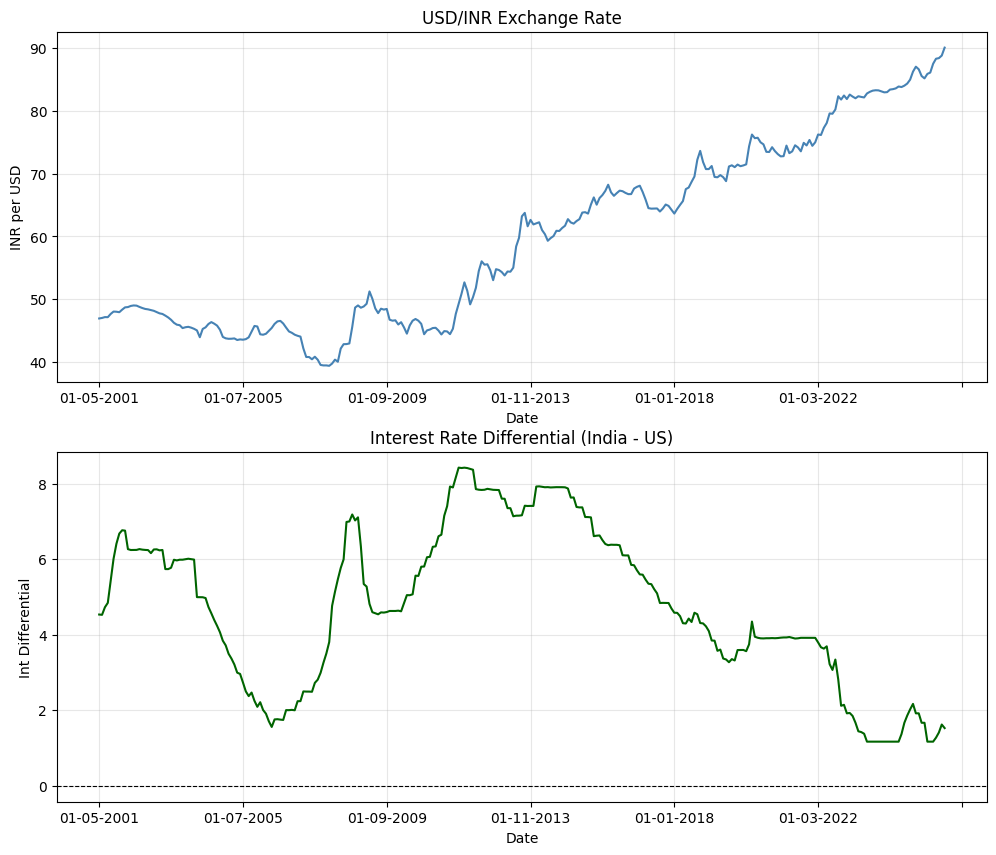

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

df['USD_INR'].plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('USD/INR Exchange Rate')
axes[0].set_ylabel('INR per USD')
axes[0].grid(alpha=0.3)

df['rate_diff'].plot(ax=axes[1], color='darkgreen', linewidth=1.5)
axes[1].set_title('Interest Rate Differential (India - US)')
axes[1].set_ylabel('Int Differential')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(alpha=0.3)
